# **📧 Email Spam Detection using RNN**
**Problem Statement**

A company receives thousands of emails every day.

They want to automatically classify emails as:

- ✅ Ham (Normal Email)
- ❌ Spam (Advertisement/Fraud)

This is a Binary Text Classification problem.

# **Why use RNN?**

Emails are sequences of words.

=> Example :

In [ ]:
# Congratulations!

# You won ₹50,000.

# Click here to claim.

=> If we shuffle the words :

In [ ]:
# Claim won congratulations click here

The meaning changes.

Since word order matters, RNN is a good model.

## **Workflow**

```
Email Dataset
↓
Load Dataset
↓
EDA
↓
Clean Text
↓
Tokenization
↓
Padding
↓
Train/Test Split
↓
Build RNN
↓
Compile
↓
Train
↓
Evaluate
↓
Prediction
↓
Confusion Matrix
↓
Accuracy Graph
↓
Loss Graph
↓
Test New Email
```

# **Step 1**
**Install Libraries**

In [1]:
!pip install tensorflow

# **Step 2**
**Import Libraries**

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, classification_report

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# **Step 3**
**Load Dataset**

Instead of downloading manually, use this small dataset.

In [9]:
url="https://raw.githubusercontent.com/justmarkham/DAT8/master/data/sms.tsv"

df=pd.read_csv(
    url,
    sep="\t",
    names=["label","message"]
)

df

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


# **Step 4**
**Explore Dataset**

In [6]:
df.shape

(5572, 2)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [10]:
df['label'].value_counts()

,count
label,
ham,4825
spam,747


# **Step 5**
**Convert Labels**

Ham = 0

Spam = 1

In [22]:
df['label'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

df.head()

,label,message
0,NaN,"Go until jurong point, crazy.. Available only ..."
1,NaN,Ok lar... Joking wif u oni...
2,NaN,Free entry in 2 a wkly comp to win FA Cup fina...
3,NaN,U dun say so early hor... U c already then say...
4,NaN,"Nah I don't think he goes to usf, he lives aro..."


# **Step 6**
**Features & Target**

In [18]:
X=df['message']

y=df['label']

# **Step 7**
**Tokenization**

Computers cannot understand text.

Convert words into numbers.

In [21]:
tokenizer = Tokenizer(num_words = 5000)

tokenizer.fit_on_texts(X)

X_seq = tokenizer.texts_to_sequences(X)


# **Step 8**
**Padding**

Each email has different lengths.

RNN requires equal length.

In [23]:
X_pad = pad_sequences(X_seq, maxlen = 100)

## **Step 9**
**Train Test Split**

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **Step 10**
**Build RNN Model**

In [31]:
model = Sequential()

model.add(
    Embedding(
        input_dim = 5000,
        output_dim = 64,
        input_length = 100
    )
)

model.add(
    SimpleRNN(64)
)

model.add(
    Dropout(0.3)
)

model.add(
    Dense(1, activation = 'sigmoid')
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


# **Step 11**
**Compile Model**

In [32]:
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

# **Step 12**
**Model Summary**

In [33]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# **Step 13**
**Train Model**

In [38]:
# url = "https://raw.githubusercontent.com/justmarkham/DAT8/master/data/sms.tsv"

# df = pd.read_csv(
#     url,
#     sep="\t",
#     names=["label","message"]
# )

# df['label'] = df['label'].map({
#     'ham': 0,
#     'spam': 1
# })

# X = df['message']
# y = df['label']

# tokenizer = Tokenizer(num_words = 5000)
# tokenizer.fit_on_texts(X)
# X_seq = tokenizer.texts_to_sequences(X)
# X_pad = pad_sequences(X_seq, maxlen = 100)

# X_train, X_test, y_train, y_test = train_test_split(
#     X_pad, y, test_size=0.2, random_state=42
# )

history = model.fit(
    X_train, y_train,
    epochs = 10,
    batch_size = 32,
    validation_split = 0.2
)

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9997 - loss: 0.0029 - val_accuracy: 0.9832 - val_loss: 0.1018
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9997 - loss: 0.0028 - val_accuracy: 0.9832 - val_loss: 0.1026
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9997 - loss: 0.0022 - val_accuracy: 0.9832 - val_loss: 0.1011
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9997 - loss: 0.0018 - val_accuracy: 0.9832 - val_loss: 0.1000
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9997 - loss: 0.0017 - val_accuracy: 0.9821 - val_loss: 0.0996
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9997 - loss: 0.0012 - val_accuracy: 0.9821 - val_loss: 0.1047
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9997 - loss: 7.4439e-04 - val_accuracy: 0.9809 - val_loss: 0.1069
Epoch 8/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 4.4457e-04 - 

# **Step 14**
**Evaluate**

In [39]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Accuracy :", accuracy)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9848 - loss: 0.0778
Accuracy : 0.9847533702850342


# **Step 15**
**Prediction**

In [40]:
pred = model.predict(X_test)

pred = (pred > 0.5)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


# **Step 16**
**Confusion Matrix**

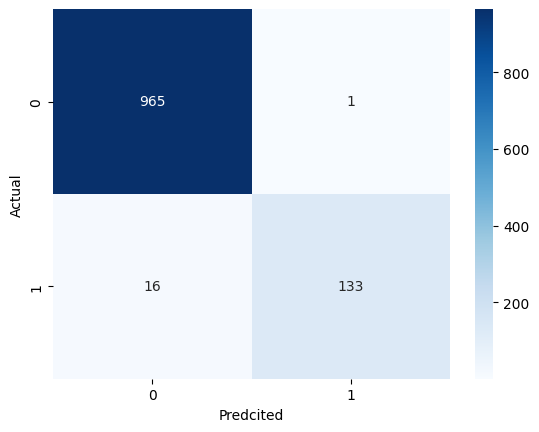

In [41]:
cm = confusion_matrix(
    y_test,
    pred
)

sns.heatmap(
    cm,
    annot = True,
    fmt = 'd',
    cmap = 'Blues'
)

plt.xlabel("Predcited")

plt.ylabel("Actual")

plt.show()

# **Step 17**
**Classification Report**

In [42]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       0.99      0.89      0.94       149

    accuracy                           0.98      1115
   macro avg       0.99      0.95      0.97      1115
weighted avg       0.98      0.98      0.98      1115



# **Step 18**
**Accuracy Graph**

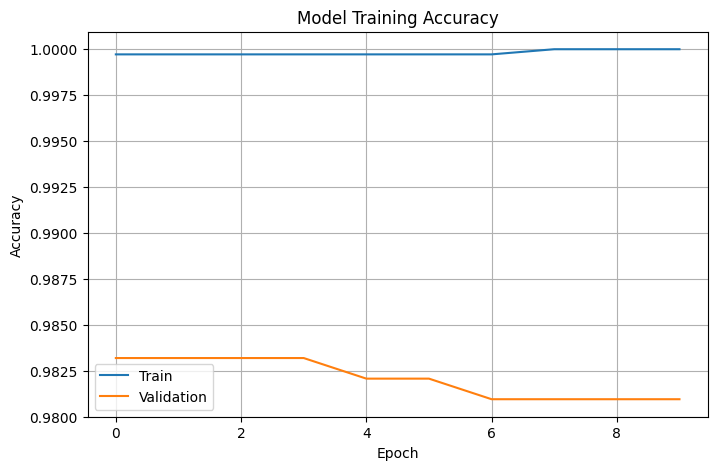

In [44]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(["Train", "Validation"])

plt.grid()

plt.show()

# **Step 19**
**Loss Graph**

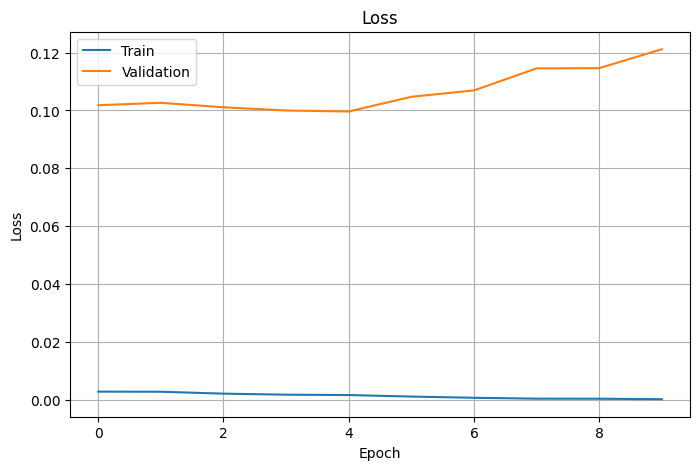

In [45]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.grid()

plt.show()

# **Step 20**
**Test Your Own Email**

In [50]:
sample=["Congratulations! You have won ₹1 Crore. Click below now."]

Convert to sequence

In [51]:
sample_seq=tokenizer.texts_to_sequences(sample)

sample_pad=pad_sequences(

sample_seq,

maxlen=100

)

prediction=model.predict(sample_pad)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step
[[0.0008133]]
